<h1>Prediciting Stock Price Movement </h1>
<h2>Spring 2026 Data Science Project </h2>

<h3 align = "center" >Contributions</h3>

<table align = "center">
  <tr>
    <th>Member</th>
    <th>Sections</th>
    <th>1–2 sentence summary</th>
  </tr>
  <tr>
    <td>Aryan Mistry</td>
    <td></td>
    <td></td>
  </tr>
  <tr >
    <td>Jason Li</td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <td>Akhil </td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <td>Arya </td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <td>Rugved </td>
    <td></td>
    <td></td>
  </tr>
</table>


<h3>Introduction</h3>
<p> Human interactions are run by socioeconomic norms driven by a common factor: money. Money is the single most important resource, utilized in almost any society. Consequently, money is always in demand, resulting in the creation of businesses. As the Internet of Things expands, technology companies become integral to meet rising consumer demand. Among thousands of technological firms, five stand out as frontrunners: Meta, Apple, Amazon, Netflix, and Google (FAANG).

FAANG has a vast influence, representing a significant part of the U.S. equity market. As a result, many consumers want to invest in the companies themselves by buying shares of ownership on the stock market. The stock market is a primary driver of wealth, but it can also be unpredictable. A company's stock can be influenced by almost anything, including scandals, public figures, and pandemics. These factors can cause fluctuations in stock price, changing either positively or negatively. Therefore, investing in the stock market creates risk, but on the other hand, it can be highly rewarding.

In an attempt to eliminate as much risk as possible, a rise in research and data analytics helps investors confidently purchase shares. To chase beating the market, models are developed to attempt to predict stock trends. For example, models utilize rational agents that attempt to identify when to buy and sell stocks based on specific features, maximizing rational utility.

As students aspiring to break into FAANG, through both the stock market and job market, the project answers a short-term investment question: Will the price of a FAANG stock increase or decrease one month from now? Answering this question carries practical values that can benefit the lives of daily wage workers and fellow college students. Furthermore, a stock prediction model’s significance doesn’t lie in just monetary value, but also the belief that advancements in machine learning create new opportunities through minimizing uncertainty. The project walks through the full analytical framework, unfolding new insights aimed to help answer next month's prediction and understand adversities that create constraints on the efficiency of the model.<p>

In [81]:
# Imports for the entire project.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_1samp
from scipy.stats import f_oneway
import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

Here's some basic information regarding the dataset that we're working with, which is a dataset with FAANG stock prices. This is essentially an initial look at the structure of the data, and a preview of the first couple of entries of data. Looking at this will be important in understanding the dataset and understanding what we need to process and clean up.

In [82]:
# Here, we're loading the stock dataset. 
stocks_df = pd.read_csv("faang_stock_prices.csv")

print("Dataset Information:")
display(stocks_df.info())

print("\nDataset Shape:", stocks_df.shape)

print("\nFirst 5 rows of data:")
display(stocks_df.head())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             14964 non-null  str    
 1   Ticker           14964 non-null  str    
 2   Open             14964 non-null  float64
 3   High             14964 non-null  float64
 4   Low              14964 non-null  float64
 5   Close            14964 non-null  float64
 6   Volume           14964 non-null  int64  
 7   SMA_7            14964 non-null  float64
 8   SMA_21           14964 non-null  float64
 9   EMA_12           14964 non-null  float64
 10  EMA_26           14964 non-null  float64
 11  RSI_14           14964 non-null  float64
 12  MACD             14964 non-null  float64
 13  MACD_Signal      14964 non-null  float64
 14  Bollinger_Upper  14964 non-null  float64
 15  Bollinger_Lower  14964 non-null  float64
 16  Daily_Return     14964 non-null  float64
 17  Vo

None


Dataset Shape: (14964, 19)

First 5 rows of data:


,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239


Before making any changes to the dataset, we check the data types and any missing values or duplicated rows. This will help when we eventually apply any sort of machine learning or regression models, to ensure that predictions will be as accurate as possible and not on faulty data.

In [83]:
# Convert the date column to datetime format, and sort the data by the date and the ticker symbol.
stocks_df["Date"] = pd.to_datetime(stocks_df["Date"])
stocks_df = stocks_df.sort_values(by=["Ticker", "Date"]).dropna()

# Check for any missing values in the dataset.
print("Missing Values Before Cleaning:")
display(stocks_df.isnull().sum())

# Drop any rows that might have missing values.
stocks_df = stocks_df.dropna()

# Check and remove any duplicated rows.
print("Duplicate Rows:", stocks_df.duplicated().sum())
stocks_df = stocks_df.drop_duplicates()

print("\nMissing Values After Cleaning:")
display(stocks_df.isnull().sum())

print("\nShape After Cleaning:", stocks_df.shape)
display(stocks_df.head())

Missing Values Before Cleaning:


Date               0
Ticker             0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_7              0
SMA_21             0
EMA_12             0
EMA_26             0
RSI_14             0
MACD               0
MACD_Signal        0
Bollinger_Upper    0
Bollinger_Lower    0
Daily_Return       0
Volatility_7d      0
Next_Day_Close     0
dtype: int64

Duplicate Rows: 0

Missing Values After Cleaning:


Date               0
Ticker             0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_7              0
SMA_21             0
EMA_12             0
EMA_26             0
RSI_14             0
MACD               0
MACD_Signal        0
Bollinger_Upper    0
Bollinger_Lower    0
Daily_Return       0
Volatility_7d      0
Next_Day_Close     0
dtype: int64


Shape After Cleaning: (14964, 19)


,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
6,2016-02-24,AAPL,21.304558,21.848618,21.154940,21.785145,145022800,21.850879,21.652174,21.730120,21.824170,50.813846,-0.094050,-0.138761,22.239524,20.975578,0.014891,0.018822,21.934757
12,2016-02-25,AAPL,21.773806,21.934757,21.592451,21.934757,110330800,21.854765,21.623132,21.761602,21.832361,50.485507,-0.070759,-0.125160,22.244062,21.058185,0.006868,0.015572,21.968756
18,2016-02-26,AAPL,22.034495,22.220383,21.893947,21.968756,115964400,21.815580,21.666249,21.793472,21.842465,60.284646,-0.048992,-0.109927,22.260391,21.117294,0.001550,0.014163,21.918888
24,2016-02-29,AAPL,21.957425,22.267995,21.909820,21.918888,140865200,21.829505,21.699797,21.812767,21.848126,56.325411,-0.035359,-0.095013,22.256425,21.118435,-0.002270,0.012012,22.789389


As we can see, the dataset that we have has pretty good data, as there weren't really anything to clean up. It's always a good safety measure to perform the cleaning process even if the data looks good from the outside. Next, we're gonna create some compound variables to help with the later functions and experiments that we call.

In [84]:
# Columns that are useful for tracking price movement.
stocks_df["Price_Range"] = stocks_df["High"] - stocks_df["Low"]
stocks_df["Open_Close_Change"] = stocks_df["Close"] - stocks_df["Open"]
stocks_df["Open_Close_Percent"] = (stocks_df["Close"] - stocks_df["Open"]) / stocks_df["Open"]

# Future 20-day return for each stock.
stocks_df["Future_Return_20d"] = (stocks_df["Close"].shift(-20) - stocks_df["Close"]) / stocks_df["Close"]
# Binary column, where 1 means the stock increase by more than 3% over the next 20 trading days, and 0 means it didn't.
stocks_df["Target"] = (stocks_df["Future_Return_20d"] > 0.03).astype(int)
display(stocks_df.head())

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,...,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close,Price_Range,Open_Close_Change,Open_Close_Percent,Future_Return_20d,Target
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,...,22.401531,20.889519,-0.022605,0.018130,21.785145,0.442049,-0.387644,-0.017739,0.127046,1
6,2016-02-24,AAPL,21.304558,21.848618,21.154940,21.785145,145022800,21.850879,21.652174,21.730120,...,22.239524,20.975578,0.014891,0.018822,21.934757,0.693678,0.480587,0.022558,0.104370,1
12,2016-02-25,AAPL,21.773806,21.934757,21.592451,21.934757,110330800,21.854765,21.623132,21.761602,...,22.244062,21.058185,0.006868,0.015572,21.968756,0.342306,0.160951,0.007392,0.092083,1
18,2016-02-26,AAPL,22.034495,22.220383,21.893947,21.968756,115964400,21.815580,21.666249,21.793472,...,22.260391,21.117294,0.001550,0.014163,21.918888,0.326436,-0.065739,-0.002983,0.085440,1
24,2016-02-29,AAPL,21.957425,22.267995,21.909820,21.918888,140865200,21.829505,21.699797,21.812767,...,22.256425,21.118435,-0.002270,0.012012,22.789389,0.358174,-0.038537,-0.001755,0.113662,1


Next, we're gonna check for rows with major outliers by the 1.5 * IQR rule. By this way, we are gonna remove rows that have extreme outliers, as they don't represent the consensus for the entire dataset. 

In [85]:
important_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "Volatility_7d",
    "Daily_Return",
    "Volume"
]

for column in important_columns:
    Q1 = stocks_df[column].quantile(0.25)
    Q3 = stocks_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column_outliers = ((stocks_df[column] < lower_bound) | (stocks_df[column] > upper_bound))

    print(f"{column}: {column_outliers.sum()} outliers")

Open: 937 outliers
High: 931 outliers
Low: 941 outliers
Close: 937 outliers
RSI_14: 5 outliers
MACD: 1987 outliers
MACD_Signal: 1972 outliers
Volatility_7d: 750 outliers
Daily_Return: 949 outliers
Volume: 2243 outliers


As you can see, there are a lot of outliers in this dataset. But, ultimately, we decided not to remove these values. In the stock market, these "outliers", especially with technology companies, can represent real events and real outcomes, as the market is volatile to changes in the real world. Thus, we keep these outliers in because there are so many, alluding to the fact that outliers are a part of the stock market and something the model needs to learn from.

**Method 1: Checking The Mean Daily Return of AAPL Stock**

In [86]:
# First, we're gonna extract the data that we need.

aapl = stocks_df[stocks_df["Ticker"] == "AAPL"]["Daily_Return"]

Before we do a T-Test, let's list out the null and alternative hypothesis:

> Null Hypothesis: The mean daily return of the AAPL stock is 0.
> <br>Alternative Hypothesis: The mean daily return of the AAPL stock differs from 0.

In [87]:
# Next, we're gonna do a T-Test on the returns for the AAPL stock.

t_stat, p_value = ttest_1samp(aapl, 0)

print("Mean Return: ", aapl.mean())
print("T-statistic: ", t_stat)
print("P-value: ", p_value)

Mean Return:  0.001138375316073588
T-statistic:  3.12303182632681
P-value:  0.0018105315125036103


Based on the P-value of 0.0018, since this P-value is significantly smaller than the alpha level of 0.05 (0.0018 < 0.05), we reject the null hypothesis. This indicates that there is strong evidence the mean daily return of AAPL is different from zero. Therefore, we can state that AAPL exhibits a statistically siginficant average return, suggesting the presence of a trend in returns rather than just stable at 0.

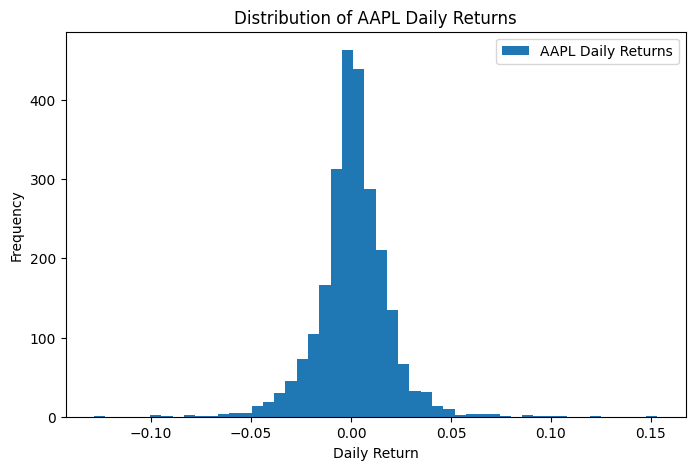

In [88]:
# Now, let's provide a plot to show this trend in average daily return.

plt.figure(figsize=(8,5))
plt.hist(aapl, bins = 50, label = 'AAPL Daily Returns')

plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

plt.show()

Looking at the histogram distribution of daily returns for the AAPL stock, we see that it seems to be approximately centered around 0. Although this seems to visually be the case, the mean return is slightly different from zero based on the t-test (0.0011). The difference is too small to be visually noticeable on the histogram since there are so many samples. The larger the sample size, the smaller the difference from the null hypothesis to be significant, as more samples should theoretically allow us to get more accurate results. As a result, the test finds that the mean return is statistically significant despite looking close to 0 on the plot.

**Method 2: Group Comparison**


In [89]:
avg_returns = stocks_df.groupby('Ticker')['Daily_Return'].mean()
print(avg_returns)

Ticker
AAPL     0.001138
AMZN     0.001061
GOOGL    0.001052
META     0.001017
MSFT     0.001053
NVDA     0.002688
Name: Daily_Return, dtype: float64


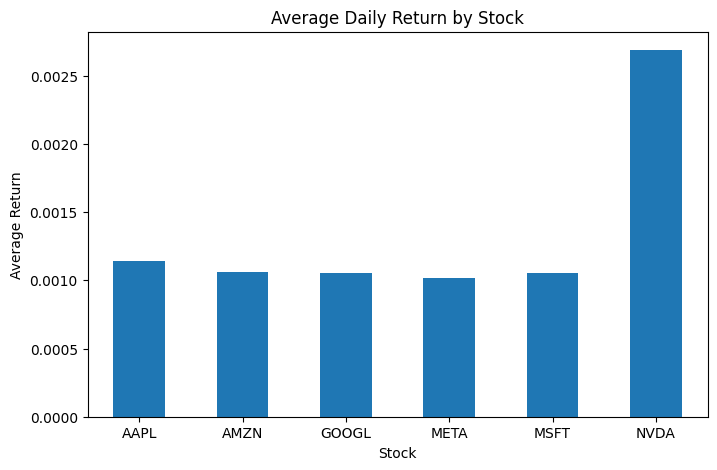

In [90]:
plt.figure(figsize=(8,5))
avg_returns.plot(kind='bar', rot = 0)
plt.title("Average Daily Return by Stock")
plt.xlabel("Stock")
plt.ylabel("Average Return")
plt.show()

Looking at the bar chart, I see that NVDA has the highest average daily return among all stocks. It is almost double compared to every other stock. The other stocks (AAPL, AMZN, GOOGL, META, MSFT) have almost similar average returns, all around 0.001. So this is the average for good companies but NVDA is an outlier with its .0025
This can mean that NVDA has a higher return on average, but this could also come with higher risk. In contrast, the other stocks appear more stable with consistent but lower returns.

**Method 3: One-Way ANOVA, Comparing Mean Daily Returns Across FAANG+ Tickers**

We want to determine whether the mean daily return differs significantly across all six 
tickers (AAPL, AMZN, GOOGL, META, MSFT, NVDA).

Before running the ANOVA test, let's state our hypotheses:

> **Null Hypothesis (H₀):** The mean daily return is the same across all FAANG+ tickers.  
> **Alternative Hypothesis (H₁):** At least one ticker has a significantly different mean daily return.

In [91]:
# Group Daily_Return by Ticker
groups = [group['Daily_Return'].dropna().values 
          for _, group in stocks_df.groupby('Ticker')]

# One-Way ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-statistic: ", f_stat)
print("P-value:     ", p_value)

F-statistic:  2.2607764069337417
P-value:      0.04573257958128592


Since the P-value is less than our alpha level of 0.05, we reject the null hypothesis.
This means there is statistically significant evidence that at least one FAANG+ ticker 
has a different mean daily return from the others. This aligns with what we observed 
visually in Method 2, where NVDA stood out with a notably higher average return (~0.0027) 
compared to the rest (~0.001).

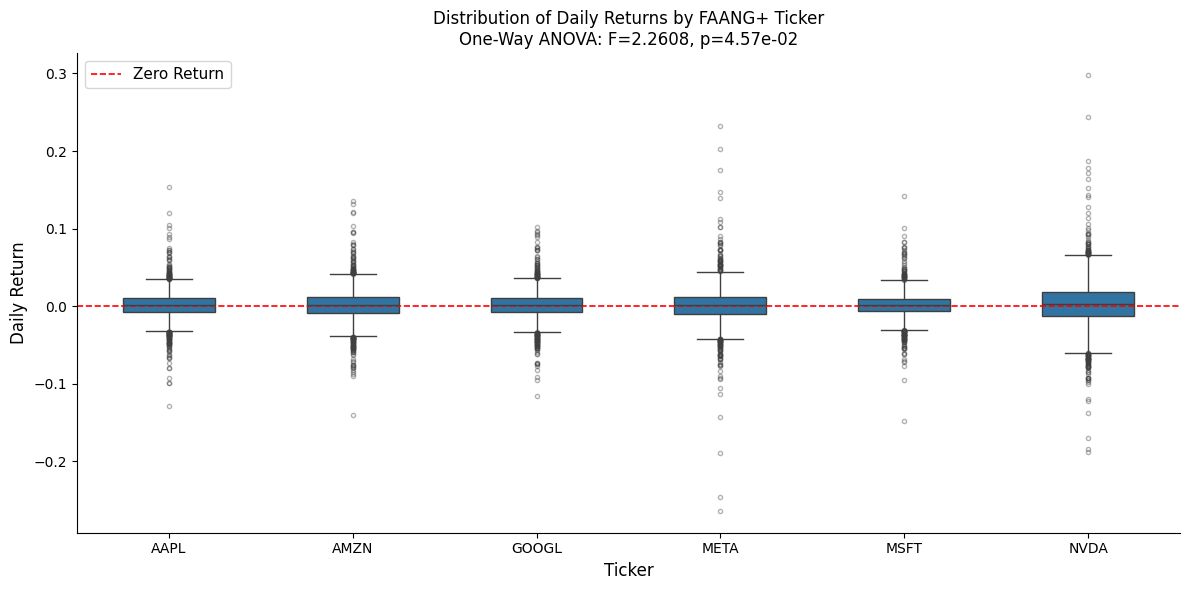

In [92]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=stocks_df,
    x='Ticker',
    y='Daily_Return',
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Zero Return')

ax.set_title(
    f'Distribution of Daily Returns by FAANG+ Ticker\n'
    f'One-Way ANOVA: F={f_stat:.4f}, p={p_value:.2e}'
)
ax.set_xlabel('Ticker', fontsize=12)
ax.set_ylabel('Daily Return', fontsize=12)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

The box plot displays the median (center line), interquartile range (box), and 
whiskers (1.5x IQR) for each FAANG+ ticker's daily returns. Small dots beyond 
the whiskers are outliers. All tickers are centered near 0, but NVDA has a 
noticeably taller box and more extreme outliers in both directions, confirming 
its higher average return and higher volatility compared to the other five stocks. 
The red dashed line at 0 serves as a reference, all six tickers sit above it on 
average, indicating consistent positive returns over the dataset's time range.

<h3>Machine learning Analysis<h3>

In [93]:

features = [
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "Volatility_7d",
    "Daily_Return",
    "Volume",
    "SMA_7",
    "SMA_21",
    "EMA_12",
    "EMA_26",
    "Bollinger_Upper",
    "Bollinger_Lower",
    "Price_Range",
    "Open_Close_Percent"
]

X = stocks_df[features]
y = stocks_df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y) # Stratify = y to deal with imbalanced data

# split = int(len(stocks_df) * 0.8)

# X_train = X.iloc[:split]
# X_test = X.iloc[split:]

# y_train = y.iloc[:split]
# y_test = y.iloc[split:] 

# train_test_split would probably be better.


In [94]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter = 1000, class_weight=  "balanced", random_state = 42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression:")
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy of Logistic Regression: {accuracy:.3f}")
print(classification_report(y_true = y_test, y_pred = y_pred_lr, target_names=['Decreases (0)', 'Increases (1)']))

# Random Forest
rf = RandomForestClassifier(n_estimators = 100, max_depth = 10, class_weight = "balanced", random_state = 42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest: {accuracy:.3f}")
print(classification_report(y_true = y_test, y_pred = y_pred_rf, target_names=['Decreases (0)', 'Increases (1)']))

# # Get probabilities for class 1
# probs = rf.predict_proba(X_test)[:, 1]

# threshold = 0.65

# # Keep only high-confidence predictions
# filter = (probs > threshold) | (probs < (1 - threshold))

# filtered_preds = (probs[filter] > 0.6).astype(int)
# filtered_true = y_test[filter]

# print("Coverage:", filter.mean())
# print(classification_report(filtered_true, filtered_preds))

Logistic Regression:
Accuracy of Logistic Regression: 0.551
               precision    recall  f1-score   support

Decreases (0)       0.58      0.49      0.53      1553
Increases (1)       0.53      0.61      0.57      1440

     accuracy                           0.55      2993
    macro avg       0.55      0.55      0.55      2993
 weighted avg       0.55      0.55      0.55      2993

Accuracy of Random Forest: 0.729
               precision    recall  f1-score   support

Decreases (0)       0.73      0.77      0.75      1553
Increases (1)       0.73      0.69      0.71      1440

     accuracy                           0.73      2993
    macro avg       0.73      0.73      0.73      2993
 weighted avg       0.73      0.73      0.73      2993



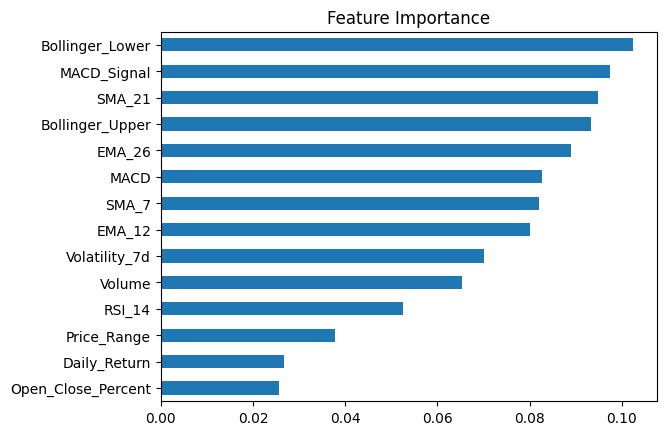

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [96]:
plt.hist(probs, bins=50)
plt.title("Prediction Probabilities (1-Month)")
plt.show()

NameError: name 'probs' is not defined

Neural Network 

In [117]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

In [222]:
probs = mlp.predict_proba(X_test_scaled)[:, 1]

threshold = 0.65

mask = (probs > threshold) | (probs < (1 - threshold))

filtered_preds = (probs[mask] > 0.5).astype(int)
filtered_true = y_test[mask]

In [ ]:
print("Coverage:", mask.mean())
print(classification_report(filtered_true, filtered_preds))